SDSSJ110731.23+134712.8: 2 file(s)
  lightcurves/acisf20114_000N020_r0001b_lc3.fits
  lightcurves/acisf21097_000N020_r0002b_lc3.fits


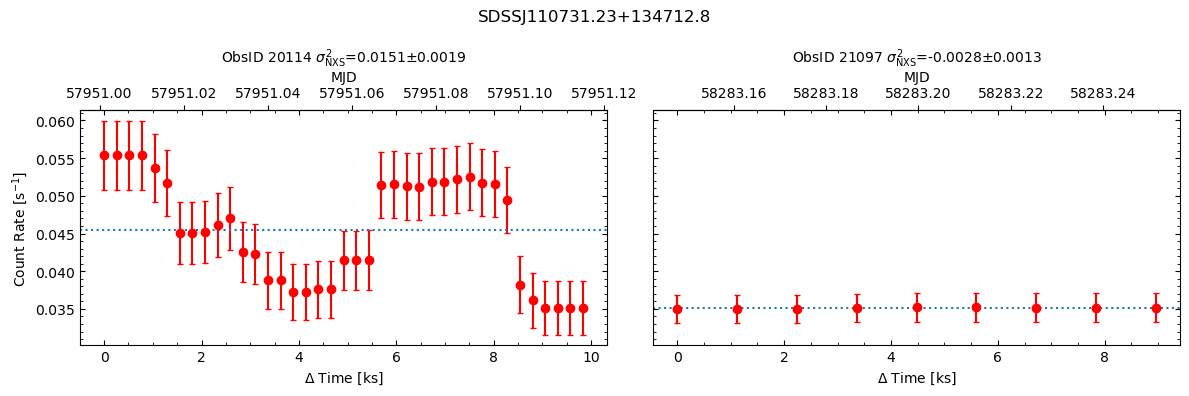

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

DIR = "lightcurves/"


def sigma_clip_lc(rate, sigma=3.0):
    """Iterative symmetric sigma clip. Returns boolean mask (True = good)."""
    mask = np.ones(len(rate), dtype=bool)
    while True:
        mu = rate[mask].mean()
        std = rate[mask].std()
        new_mask = np.abs(rate - mu) <= sigma * std
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return mask, mu, std


def nxs_variance(rate, err):
    """Normalized excess variance and uncertainty (Vaughan et al. 2003)."""
    n = len(rate)
    mu = rate.mean()
    nxs = np.sum((rate - mu)**2 - err**2) / (n * mu**2)
    nxs_err = np.sqrt(
        (np.sqrt(2 / n) * np.mean(err**2) / mu**2)**2 +
        (np.sqrt(np.mean(err**2) / n) * 2 * nxs / mu)**2
    )
    return nxs, nxs_err


# --- Step 1: scan folder and group files by sky position (RA_TARG/DEC_TARG) ---
lc_dir = Path(DIR)
match_radius = 1 * u.arcmin

file_info = []
for fits_path in sorted(lc_dir.glob("*.fits")):
    with fits.open(fits_path) as hdul:
        h = hdul["LIGHTCURVE"].header
        file_info.append(dict(
            path=str(fits_path),
            obj=h.get("OBJECT", "UNKNOWN"),
            ra=h.get("RA_TARG"),
            dec=h.get("DEC_TARG"),
        ))

# Greedy grouping by sky position
groups = []
for info in file_info:
    coord = SkyCoord(ra=info["ra"] * u.deg, dec=info["dec"] * u.deg)
    matched = None
    for g in groups:
        if g["coord"].separation(coord) < match_radius:
            matched = g
            break
    if matched:
        matched["paths"].append(info["path"])
    else:
        groups.append({"label": info["obj"], "coord": coord, "paths": [info["path"]]})

object_files = {g["label"]: g["paths"] for g in groups}

for obj, paths in object_files.items():
    print(f"{obj}: {len(paths)} file(s)")
    for p in paths:
        print(f"  {p}")

gcol = "red"
sigma = 3.0

for obj_name, paths in object_files.items():
    obs = []
    for path in paths:
        with fits.open(path) as hdul:
            tbl = hdul["LIGHTCURVE"].data
            header = hdul["LIGHTCURVE"].header
            obs.append(dict(
                path=path,
                t=tbl["Time"],
                rate=tbl["COUNT_RATE"],
                err=tbl["COUNT_RATE_ERR"],
                obsid=header.get("OBS_ID", ""),
                fname=path.split("/")[-1],
                mjd_obs=header.get("MJD-OBS"),
            ))

    obs.sort(key=lambda d: d["mjd_obs"])

    fig, axes = plt.subplots(1, len(obs), figsize=(6 * len(obs), 4), sharey=True)
    if len(obs) == 1:
        axes = [axes]

    for ax, d in zip(axes, obs):
        mask, _, _ = sigma_clip_lc(d["rate"], sigma=sigma)
        mean_good = d["rate"][mask].mean()
        t_ks = (d["t"] - d["t"][0]) / 1e3
        nxs, nxs_err = nxs_variance(d["rate"], d["err"])

        ax.minorticks_on()
        ax.tick_params(axis="both", direction="in", which="both",
                       bottom=True, top=True, left=True, right=True)

        if any(~mask):
            ax.plot(t_ks[~mask], d["rate"][~mask],
                    marker="s", ms=3.5, ls="none", color="blue", fillstyle="full")
        ax.errorbar(t_ks[mask], d["rate"][mask], yerr=d["err"][mask],
                    marker="o", ms=6, ls="none", capsize=2, color=gcol, fillstyle="full")
        ax.axhline(mean_good, linestyle="dotted")
        ax.set_xlabel(r"$\Delta$ Time [ks]", fontsize=10)
        ax.set_title(
            rf"ObsID {d['obsid']} $\sigma^2_{{\rm NXS}}$={nxs:.4f}$\pm${nxs_err:.4f}",
            fontsize=10
        )

        ax_mjd = ax.secondary_xaxis(
            "top",
            functions=(lambda x, m=d["mjd_obs"]: m + x * 1e3 / 86400,
                       lambda x, m=d["mjd_obs"]: (x - m) * 86400 / 1e3)
        )
        ax_mjd.xaxis.get_major_formatter().set_useOffset(False)
        ax_mjd.set_xlabel("MJD", fontsize=10)

    axes[0].set_ylabel(r"Count Rate $\left[\mathrm{s}^{-1}\right]$", fontsize=10)
    plt.suptitle(obj_name)
    plt.tight_layout()
    safe_name = obj_name.replace(" ", "_").replace("/", "-")
    plt.savefig(f"{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()